**Feed the Processed data to Regression model**

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
from os import error

Adding the Processed data to pandas DataFrame

In [2]:
path ="/Users/soujanyadutta/VS_Code_file/Nasa_Turbofan_Rul_Prediction/train_processed.csv"
df = pd.read_csv(path)
#df = df.sample(frac=0.10, random_state=42)

In [3]:
path ="/Users/soujanyadutta/VS_Code_file/Nasa_Turbofan_Rul_Prediction/CMaps/processed_data.csv"
df = pd.read_csv(path)

In [4]:
df.count()

unit_number                20631
time_cycles                20631
setting_1                  20631
setting_2                  20631
setting_3                  20631
                           ...  
op_mode_-0.0_0.0_100.0     20631
op_mode_0.01_-0.0_100.0    20631
op_mode_0.01_0.0_100.0     20631
op_mode_0.0_-0.0_100.0     20631
op_mode_0.0_0.0_100.0      20631
Length: 90, dtype: int64

In [5]:
df.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_6,s_7,...,s_20_delta,s_21_delta,op_mode_-0.01_-0.0_100.0,op_mode_-0.01_0.0_100.0,op_mode_-0.0_-0.0_100.0,op_mode_-0.0_0.0_100.0,op_mode_0.01_-0.0_100.0,op_mode_0.01_0.0_100.0,op_mode_0.0_-0.0_100.0,op_mode_0.0_0.0_100.0
0,1,1,-0.0007,-0.0004,100.0,-1.764435,-0.181529,-0.781452,1.825742e-01,0.890071,...,NaN,NaN,False,False,True,False,False,False,False,False
1,1,2,0.0019,-0.0003,100.0,-1.091783,0.192667,-0.914629,2.948839e-01,0.395547,...,-0.127297,0.131857,False,False,False,False,False,False,True,False
2,1,3,-0.0043,0.0003,100.0,-0.949037,-1.039827,-1.746960,0.000000e+00,1.886975,...,0.312402,0.030245,False,False,False,True,False,False,False,False
3,1,4,0.0007,0.0000,100.0,-0.837075,-1.425192,-0.920815,0.000000e+00,1.310648,...,-0.847574,-0.251861,False,False,False,False,False,False,False,True
4,1,5,-0.0019,-0.0002,100.0,-0.780706,-1.058901,-0.134130,-3.552714e-15,0.410518,...,-0.399081,-0.237177,False,False,True,False,False,False,False,False


In [6]:
sample_df = df.sample(frac=0.1, random_state=42)

In [7]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2063 entries, 13857 to 18261
Data columns (total 90 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   unit_number                2063 non-null   int64  
 1   time_cycles                2063 non-null   int64  
 2   setting_1                  2063 non-null   float64
 3   setting_2                  2063 non-null   float64
 4   setting_3                  2063 non-null   float64
 5   s_2                        2063 non-null   float64
 6   s_3                        2063 non-null   float64
 7   s_4                        2063 non-null   float64
 8   s_6                        2063 non-null   float64
 9   s_7                        2063 non-null   float64
 10  s_8                        2063 non-null   float64
 11  s_9                        2063 non-null   float64
 12  s_11                       2063 non-null   float64
 13  s_12                       2063 non-null   float

In [8]:
x =df.drop("RUL", axis=1)
y = df["RUL"]


Spliting the data for 80% trainning and 20% testing

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [10]:
print(type(x_train))
print(type(y_train))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


**Implementing XGBRegressor model**

In [11]:
import pandas as pd
from xgboost import XGBRegressor

# Suppose df_train, df_test, y_train are already defined

# 1. Find all op_mode_* columns that actually exist in df_train and df_test
op_mode_cols_train = [col for col in x_train.columns if col.startswith('op_mode_')]
op_mode_cols_test = [col for col in x_test.columns if col.startswith('op_mode_')]

# Take the intersection to avoid missing columns
op_mode_cols = list(set(op_mode_cols_train) & set(op_mode_cols_test))
print("Columns to process:", op_mode_cols)

# 2. Convert these columns to numeric (or category)
x_train[op_mode_cols] = x_train[op_mode_cols].apply(pd.to_numeric, errors='coerce')
x_test[op_mode_cols] = x_test[op_mode_cols].apply(pd.to_numeric, errors='coerce')

#X_train[s_14_Rolling_diffrence_5] = X_train[s_14_Rolling_diffrence_5].apply(pd.to_numeric, erros='coerce')
#X_test[]
#Optional: if you want categorical type instead
#x_train[op_mode_cols] = x_train[op_mode_cols].astype('category')
#x_test[op_mode_cols] = x_test[op_mode_cols].astype('category')

# 3. Define the XGBRegressor
model_1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True  # only needed if columns are categorical
)

# 4. Fit the model
model_1.fit(x_train, y_train)

# 5. Make predictions
preds_train = model_1.predict(x_train)
preds_test = model_1.predict(x_test)

print("Training predictions sample:", preds_train[:5])
print("Test predictions sample:", preds_test[:5])

Columns to process: ['op_mode_-0.0_0.0_100.0', 'op_mode_0.01_-0.0_100.0', 'op_mode_0.0_0.0_100.0', 'op_mode_-0.01_0.0_100.0', 'op_mode_0.01_0.0_100.0', 'op_mode_0.0_-0.0_100.0', 'op_mode_-0.0_-0.0_100.0', 'op_mode_-0.01_-0.0_100.0']
Training predictions sample: [166.76414 111.12882 111.70761 133.61565 244.54196]
Test predictions sample: [148.6482       2.9453895  213.57332      0.42730197 167.5789    ]


In [12]:
print(x_train.columns)

Index(['unit_number', 'time_cycles', 'setting_1', 'setting_2', 'setting_3',
       's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13',
       's_15', 's_17', 's_20', 's_21', 's_2_Rolling_diffrence_5',
       's_3_Rolling_diffrence_5', 's_4_Rolling_diffrence_5',
       's_6_Rolling_mean_5', 's_6_Rolling_diffrence_5',
       's_7_Rolling_diffrence_5', 's_8_Rolling_diffrence_5',
       's_9_Rolling_diffrence_5', 's_11_Rolling_diffrence_5',
       's_12_Rolling_diffrence_5', 's_13_Rolling_diffrence_5',
       's_14_Rolling_diffrence_5', 's_15_Rolling_diffrence_5',
       's_17_Rolling_diffrence_5', 's_20_Rolling_diffrence_5',
       's_21_Rolling_diffrence_5', 's_2_Rolling_diffrence_10',
       's_3_Rolling_diffrence_10', 's_4_Rolling_diffrence_10',
       's_6_Rolling_mean_10', 's_6_Rolling_diffrence_10',
       's_7_Rolling_diffrence_10', 's_8_Rolling_diffrence_10',
       's_9_Rolling_diffrence_10', 's_11_Rolling_diffrence_10',
       's_12_Rolling_diffrence_10', 's

In [13]:
op_mode_cols = [col for col in x_train.columns if col.startswith('op_mode_')]
print("Columns to fix:", op_mode_cols)

Columns to fix: ['op_mode_-0.01_-0.0_100.0', 'op_mode_-0.01_0.0_100.0', 'op_mode_-0.0_-0.0_100.0', 'op_mode_-0.0_0.0_100.0', 'op_mode_0.01_-0.0_100.0', 'op_mode_0.01_0.0_100.0', 'op_mode_0.0_-0.0_100.0', 'op_mode_0.0_0.0_100.0']


In [14]:
x_train[op_mode_cols] = x_train[op_mode_cols].apply(pd.to_numeric, errors='coerce')

In [15]:
model_1 =XGBRegressor()

model_1.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


**Evulate XGBRegressor model**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [500, 600, 700],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.10],
    'subsample': [0.5, 0.7, 0.9],
    'colsample_bytree': [0.5, 0.7, 0.9]
}

grid_search = GridSearchCV(
    estimator=model_1,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # Use RMSE or other metrics if you like
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearch
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [500, 700, 900],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05]
}

grid_search = GridSearchCV(
    estimator=model_1,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # Use RMSE or other metrics if you like
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found:  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 900}


In [17]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_1, x_train, y_train, cv=5)  # 5-fold CV
print("CV scores:", scores)
print("Average CV score:", scores.mean())
# Fit GridSearch
grid_search.fit(x_train, y_train)

CV scores: [0.96546906 0.96010447 0.96507871 0.96249866 0.96227878]
Average CV score: 0.9630859375
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.03, ...], 'max_depth': [5, 7, ...], 'n_estimators': [500, 700, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [18]:
best_params = grid_search.best_params_
print((grid_search.best_params_))
print(grid_search.best_score_)


{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 900}
-10.211161295572916


In [19]:
best_model = XGBRegressor(**best_params)
best_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [20]:
y_pred = best_model.predict(x_test)
rsme = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
R2_score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Root Mean Squared Error:", rsme)
print("Mean Squared Error:", mse)
print("R2_score:", R2_score)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)

Root Mean Squared Error: 8.73206615447998
Mean Squared Error: 76.24898529052734
R2_score: 0.9833109378814697
Mean Absolute Error: 6.603721618652344
Mean Absolute Percentage Error: 62163678920704.0


In [12]:
y_pred = model_1.predict(x_test)
rsme = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
R2_score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Root Mean Squared Error:", rsme)
print("Mean Squared Error:", mse)
print("R2_score:", R2_score)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)

Root Mean Squared Error: 12.019428253173828
Mean Squared Error: 144.46665954589844
R2_score: 0.9683796763420105
Mean Absolute Error: 8.969666481018066
Mean Absolute Percentage Error: 121307744174080.0


NASA_phm_score

In [35]:
print(type(y_pred))
print(type(y_test))
y_test = y_test.to_numpy()
print(type(y_test))


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>


In [37]:
def NASA_phm_score(y_true, y_pred):
    score = 0
    for true, pred in zip(y_true, y_pred):

        error = pred - true
        if error < 0:
            score += np.exp(-error/13) - 1
        else:
            score += np.exp(error/10) - 1
    return score

print("NASA_PHM Score:", NASA_phm_score(y_test, y_pred))


NASA_PHM Score: [4748.89874182]


**MC_Dropout for Mean & Uncertainty Predict**

In [ ]:
import numpy as np
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.utils import resample

def xgb_ensemble_predictions(X_train, y_train, X_test, n_models=30):
    """
    Train an ensemble of XGBRegressor models on bootstrapped samples and
    return mean and std predictions for X_test.
    """
    preds = []

    for i in range(n_models):
        # Bootstrap sample
        X_resampled, y_resampled = resample(X_train, y_train, random_state=i)

        # Train XGB model
        model = XGBRegressor(n_estimators=100, random_state=i)
        model.fit(X_resampled, y_resampled)

        # Predict
        preds.append(model.predict(X_test))

    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    std_pred = preds.std(axis=0)

    return mean_pred, std_pred

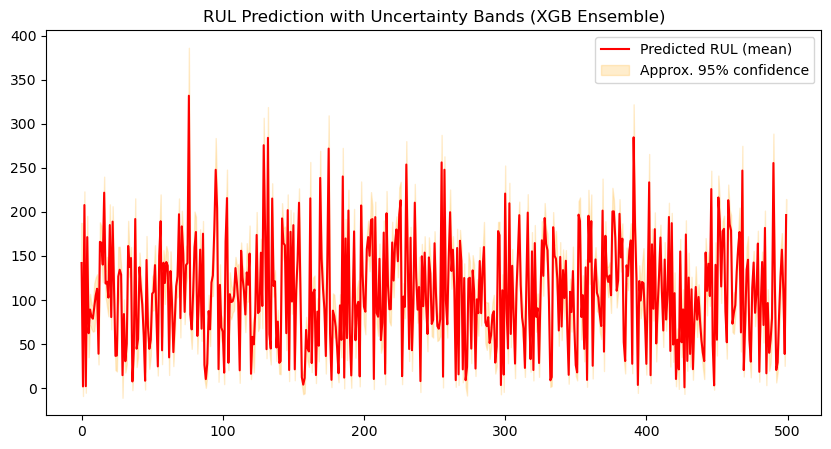

In [39]:
# Assuming X_train, y_train, X_test are already defined
y_mean, y_std = xgb_ensemble_predictions(x_train, y_train, x_test[:500], n_models=30)

plt.figure(figsize=(10,5))
plt.plot(y_mean, label="Predicted RUL (mean)", color="red")
plt.fill_between(range(len(y_mean)), y_mean - 2*y_std, y_mean + 2*y_std,
                 alpha=0.2, color="orange", label="Approx. 95% confidence")
plt.legend()
plt.title("RUL Prediction with Uncertainty Bands (XGB Ensemble)")
plt.show()


In [41]:
y_mean, y_std = xgb_ensemble_predictions(x_train, y_train, x_test[:500], n_models=30)
mean_prediction = y_mean
uncertainty = y_std
print("Mean Prediction:", mean_prediction)
print("Uncertainty:", uncertainty)

Mean Prediction: [141.94637      1.9359558  207.72171      2.1979196  171.34065
  62.350845    89.16572     81.16232     78.77982     91.89948
 105.016075   112.760796    39.042187   165.96808    165.0029
 140.1403     221.75568    118.66524    120.745445   102.710236
 185.03947     80.61756    188.91815    113.665764    36.579853
  37.034706   126.62473    134.35675    128.848       14.716784
  84.06866     30.562103    50.36683    161.2922     137.35756
 147.65698      7.6200204   43.494484   191.88307     44.737305
  55.723553   137.19019    113.01509     94.80404     60.140903
   8.402287   145.40338     70.48815     44.598824    54.71632
 107.07585    109.13461    139.5777      84.10325     24.693077
 150.0209     189.37483     42.9135     142.28613    119.33011
 143.0938     138.88768     34.886105   132.82254     99.500626
  40.85488     76.241486   115.61351    126.94214    197.31317
  79.39347    183.53847    152.83754     86.49155    139.66347
 141.92412    331.74835     83.7

**CONFIDANCE INTERVAL EVALUATION 95% CI**

In [42]:
lower = mean_prediction - 1.96 * uncertainty
upper = mean_prediction + 1.96 * uncertainty
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: [ 9.72932739e+01 -8.67691994e+00  1.92580048e+02 -5.05011654e+00
  1.47794189e+02  3.56510963e+01  7.17213745e+01  6.74487305e+01
  6.43561935e+01  6.53210449e+01  8.49527740e+01  9.67248688e+01
  2.71925392e+01  1.44194519e+02  1.46235580e+02  1.20813835e+02
  2.03966736e+02  1.04504715e+02  9.31580048e+01  8.20068893e+01
  1.62022629e+02  6.70578918e+01  1.71840790e+02  9.54500504e+01
  2.08537006e+01  1.93627281e+01  9.36137848e+01  1.08795532e+02
  1.19803719e+02 -1.04060841e+01  6.78400879e+01  1.79640732e+01
  2.72971916e+01  1.33387527e+02  1.26162079e+02  1.35423782e+02
 -2.06902742e+00  2.74545021e+01  1.68938080e+02  2.43728714e+01
  3.54928284e+01  1.20885017e+02  9.74885101e+01  8.29105377e+01
  4.46287041e+01 -1.34001255e+00  1.18771942e+02  5.14533691e+01
  2.23396530e+01  3.69224396e+01  8.79406815e+01  8.87419357e+01
  1.17472488e+02  6.06414452e+01  1.45940971e+01  1.27049347e+02
  1.59584885e+02  2.75482464e+01  1.28146332e+02  9.59617462e+01
  1.25277153

**RPI**

In [43]:
RPI = (upper - lower) / np.abs(mean_prediction)
print("RPI:", RPI)

RPI: [ 0.62915444 10.963965    0.14578797  6.5953608   0.27484968  0.8564359
  0.39127916  0.33793002  0.36617574  0.5784241   0.38209963  0.2844238
  0.60701764  0.2623825   0.22747865  0.27581596  0.1604373   0.23866336
  0.45695207  0.40314087  0.24877769  0.33639494  0.18079112  0.3205137
  0.85982597  0.9543469   0.5213981   0.38049772  0.14038688  3.414179
  0.38607895  0.82442164  0.9160646   0.34601396  0.16301222  0.16569754
  2.5430503   0.73756397  0.23915598  0.91040057  0.72611034  0.23770173
  0.27477005  0.25090706  0.5158619   2.3189635   0.36631113  0.5400846
  0.9981954   0.6504049   0.35741335  0.37371612  0.31674415  0.55792856
  0.81796044  0.30624476  0.31461358  0.7161035   0.19875164  0.3916591
  0.24902043  0.21981856  1.1186433   0.3293802   0.25682342  0.76102084
  0.48373976  0.2397453   0.35163763  0.17759891  0.5390326   0.18849508
  0.2535851   0.31397858  0.30896696  0.20679784  0.3213006   0.35917082
  0.64843416  0.41744715  0.49415916  0.19269723  0.6

FINDING THE BEST PARAMETER FOR XGBOOST MODEL WITH OPYUNA

In [44]:
!pip install Optuna
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    # Hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),

        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),

        # Regularization paramaters
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_beta": trial.suggest_float("reg_beta", 1e-8, 10.0, log=True),

        # Tree Method
        "tree_method": "hist",
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    # Build model
    model = XGBRegressor(**params)

    # Fit model
    model.fit(
        x_train, y_train,
        eval_set=[(x_test, y_test)],

        verbose=False
    )

     # Predict & calculate RMSE
    preds = model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse

/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [49]:
study = optuna.create_study(directions = ["minimize"])
study.optimize(objective, n_trials=40, show_progress_bar = True)  # increase trials for better

[I 2026-01-20 23:37:23,435] A new study created in memory with name: no-name-1353f8eb-6396-4a95-aef9-e6a6b75d4b1c
  0%|          | 0/40 [00:00<?, ?it/s]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:37:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 15.6215:   2%|▎         | 1/40 [00:04<03:04,  4.73s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:37:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:37:28,166] Trial 0 finished with value: 15.621458094650757 and parameters: {'n_estimators': 1189, 'max_depth': 5, 'learning_rate': 0.011727959304500761, 'subsample': 0.8866281193091041, 'colsample_bytree': 0.5347375208400931, 'gamma': 4.407709157833176, 'min_child_weight': 17, 'reg_alpha': 0.0008007404628912538, 'reg_beta': 2.142820915478527e-08}. Best is trial 0 with value: 15.621458094650757.


Best trial: 0. Best value: 15.6215:   5%|▌         | 2/40 [00:09<02:50,  4.49s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:37:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:37:32,488] Trial 1 finished with value: 19.925429370422687 and parameters: {'n_estimators': 1299, 'max_depth': 11, 'learning_rate': 0.2956519370669503, 'subsample': 0.5324544215832783, 'colsample_bytree': 0.7382304821097834, 'gamma': 6.907071888438714, 'min_child_weight': 13, 'reg_alpha': 1.027838318208349e-06, 'reg_beta': 0.005501585891531479}. Best is trial 0 with value: 15.621458094650757.


Best trial: 2. Best value: 15.4315:   8%|▊         | 3/40 [00:14<03:01,  4.91s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:37:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:37:37,908] Trial 2 finished with value: 15.431503057741775 and parameters: {'n_estimators': 217, 'max_depth': 13, 'learning_rate': 0.07547971603405594, 'subsample': 0.720792510311671, 'colsample_bytree': 0.7604694722906122, 'gamma': 5.7314600779412315, 'min_child_weight': 6, 'reg_alpha': 5.74275241220479e-06, 'reg_beta': 0.5008298763892804}. Best is trial 2 with value: 15.431503057741775.


Best trial: 3. Best value: 14.1292:  10%|█         | 4/40 [00:22<03:37,  6.04s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:37:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:37:45,678] Trial 3 finished with value: 14.129191899068507 and parameters: {'n_estimators': 1936, 'max_depth': 13, 'learning_rate': 0.08035317968893703, 'subsample': 0.574457924463942, 'colsample_bytree': 0.724370258513809, 'gamma': 7.592035143680346, 'min_child_weight': 13, 'reg_alpha': 0.00014596497961511743, 'reg_beta': 1.1652979576522622}. Best is trial 3 with value: 14.129191899068507.


Best trial: 3. Best value: 14.1292:  12%|█▎        | 5/40 [00:24<02:38,  4.54s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:37:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:37:47,557] Trial 4 finished with value: 29.667188775543767 and parameters: {'n_estimators': 516, 'max_depth': 4, 'learning_rate': 0.007243727201622622, 'subsample': 0.5520463242337224, 'colsample_bytree': 0.9811018958290589, 'gamma': 8.597693660600669, 'min_child_weight': 20, 'reg_alpha': 0.00121570933754871, 'reg_beta': 5.63425653699104e-06}. Best is trial 3 with value: 14.129191899068507.


Best trial: 3. Best value: 14.1292:  15%|█▌        | 6/40 [00:29<02:49,  4.99s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:37:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:37:53,411] Trial 5 finished with value: 27.66090179804791 and parameters: {'n_estimators': 1785, 'max_depth': 4, 'learning_rate': 0.002653167757314556, 'subsample': 0.7065750964807824, 'colsample_bytree': 0.7548403825650623, 'gamma': 3.63600732565724, 'min_child_weight': 3, 'reg_alpha': 0.0001701301440600738, 'reg_beta': 0.05675502672109197}. Best is trial 3 with value: 14.129191899068507.


Best trial: 3. Best value: 14.1292:  18%|█▊        | 7/40 [00:34<02:35,  4.70s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:37:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:37:57,512] Trial 6 finished with value: 18.62688748825203 and parameters: {'n_estimators': 1730, 'max_depth': 3, 'learning_rate': 0.014597355761960596, 'subsample': 0.5499422343096931, 'colsample_bytree': 0.6330109410850271, 'gamma': 3.937941400228456, 'min_child_weight': 20, 'reg_alpha': 0.0011330412868185513, 'reg_beta': 9.179334916031745e-07}. Best is trial 3 with value: 14.129191899068507.


Best trial: 3. Best value: 14.1292:  20%|██        | 8/40 [00:45<03:41,  6.92s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:38:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:38:09,187] Trial 7 finished with value: 25.239705319384672 and parameters: {'n_estimators': 1832, 'max_depth': 6, 'learning_rate': 0.001684588901334761, 'subsample': 0.8118327064711259, 'colsample_bytree': 0.9927993042148369, 'gamma': 2.5597725457447806, 'min_child_weight': 19, 'reg_alpha': 4.875283156055589e-07, 'reg_beta': 0.13444103939431784}. Best is trial 3 with value: 14.129191899068507.


Best trial: 8. Best value: 11.8131:  22%|██▎       | 9/40 [01:01<05:03,  9.80s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:38:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:38:25,307] Trial 8 finished with value: 11.813064480973624 and parameters: {'n_estimators': 1309, 'max_depth': 9, 'learning_rate': 0.022562745160045982, 'subsample': 0.5150523109359735, 'colsample_bytree': 0.9381928949562274, 'gamma': 7.545117724120236, 'min_child_weight': 7, 'reg_alpha': 3.2135298925349713e-05, 'reg_beta': 0.6359435407908824}. Best is trial 8 with value: 11.813064480973624.


Best trial: 9. Best value: 10.9945:  25%|██▌       | 10/40 [01:06<04:09,  8.32s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:38:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:38:30,317] Trial 9 finished with value: 10.994505116704001 and parameters: {'n_estimators': 1423, 'max_depth': 7, 'learning_rate': 0.1471671593975811, 'subsample': 0.8571247981532564, 'colsample_bytree': 0.7729275112383874, 'gamma': 3.288486853424981, 'min_child_weight': 19, 'reg_alpha': 0.0001265269335503184, 'reg_beta': 0.04301276392729388}. Best is trial 9 with value: 10.994505116704001.


Best trial: 9. Best value: 10.9945:  28%|██▊       | 11/40 [01:10<03:21,  6.95s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:38:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:38:34,163] Trial 10 finished with value: 12.294800715497143 and parameters: {'n_estimators': 729, 'max_depth': 7, 'learning_rate': 0.2844065466163057, 'subsample': 0.9936771040587319, 'colsample_bytree': 0.8619660667092122, 'gamma': 0.09086081197013307, 'min_child_weight': 15, 'reg_alpha': 1.0157770009952303, 'reg_beta': 0.00022788272174613258}. Best is trial 9 with value: 10.994505116704001.


Best trial: 9. Best value: 10.9945:  30%|███       | 12/40 [01:20<03:41,  7.92s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:38:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:38:44,315] Trial 11 finished with value: 11.43742195477983 and parameters: {'n_estimators': 1429, 'max_depth': 9, 'learning_rate': 0.05222972845376186, 'subsample': 0.8593493131947211, 'colsample_bytree': 0.8842459803950269, 'gamma': 1.4629942164196017, 'min_child_weight': 8, 'reg_alpha': 1.2160671524636205e-08, 'reg_beta': 0.0033230883036859905}. Best is trial 9 with value: 10.994505116704001.


Best trial: 9. Best value: 10.9945:  32%|███▎      | 13/40 [01:29<03:40,  8.15s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:38:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:38:52,987] Trial 12 finished with value: 11.704894804223132 and parameters: {'n_estimators': 1500, 'max_depth': 9, 'learning_rate': 0.069265196943167, 'subsample': 0.8820093367166176, 'colsample_bytree': 0.8569720272013478, 'gamma': 0.9688700420994795, 'min_child_weight': 9, 'reg_alpha': 1.5816529484748913e-08, 'reg_beta': 0.0010015667339911198}. Best is trial 9 with value: 10.994505116704001.


Best trial: 13. Best value: 10.6782:  35%|███▌      | 14/40 [01:41<03:58,  9.18s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:39:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:39:04,547] Trial 13 finished with value: 10.678151107367668 and parameters: {'n_estimators': 908, 'max_depth': 8, 'learning_rate': 0.040101343200021386, 'subsample': 0.8263004414504445, 'colsample_bytree': 0.8635546570233582, 'gamma': 1.9503003192100459, 'min_child_weight': 1, 'reg_alpha': 0.21683776116480105, 'reg_beta': 0.00011440494059968947}. Best is trial 13 with value: 10.678151107367668.


Best trial: 13. Best value: 10.6782:  38%|███▊      | 15/40 [01:45<03:11,  7.65s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:39:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:39:08,637] Trial 14 finished with value: 11.444493891373593 and parameters: {'n_estimators': 768, 'max_depth': 7, 'learning_rate': 0.15661906259502167, 'subsample': 0.966188525632434, 'colsample_bytree': 0.8122201066108178, 'gamma': 2.37820089196904, 'min_child_weight': 4, 'reg_alpha': 0.11839157847312512, 'reg_beta': 2.885097305987054e-05}. Best is trial 13 with value: 10.678151107367668.


Best trial: 15. Best value: 9.8961:  40%|████      | 16/40 [01:52<03:04,  7.69s/it] /Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:39:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:39:16,430] Trial 15 finished with value: 9.896102955139991 and parameters: {'n_estimators': 955, 'max_depth': 7, 'learning_rate': 0.03252613800815668, 'subsample': 0.7677879104569209, 'colsample_bytree': 0.6669976384286368, 'gamma': 2.7087639580608815, 'min_child_weight': 1, 'reg_alpha': 0.020409367918001, 'reg_beta': 0.01550613671709991}. Best is trial 15 with value: 9.896102955139991.


Best trial: 15. Best value: 9.8961:  42%|████▎     | 17/40 [02:08<03:48,  9.93s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:39:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:39:31,582] Trial 16 finished with value: 14.164293576610662 and parameters: {'n_estimators': 955, 'max_depth': 11, 'learning_rate': 0.029534817210084167, 'subsample': 0.6566459358699612, 'colsample_bytree': 0.6568443716135157, 'gamma': 5.415269914081348, 'min_child_weight': 1, 'reg_alpha': 0.03212394197133047, 'reg_beta': 0.00010150493145173329}. Best is trial 15 with value: 9.896102955139991.


Best trial: 15. Best value: 9.8961:  45%|████▌     | 18/40 [02:44<06:32, 17.84s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:40:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:40:07,820] Trial 17 finished with value: 15.485909733320632 and parameters: {'n_estimators': 947, 'max_depth': 11, 'learning_rate': 0.005791991965423358, 'subsample': 0.7835461502670568, 'colsample_bytree': 0.6622812172718497, 'gamma': 1.6688713214238895, 'min_child_weight': 1, 'reg_alpha': 8.30450181795741, 'reg_beta': 9.468174226801015}. Best is trial 15 with value: 9.896102955139991.


Best trial: 15. Best value: 9.8961:  48%|████▊     | 19/40 [03:03<06:24, 18.33s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:40:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:40:27,301] Trial 18 finished with value: 17.19059897488259 and parameters: {'n_estimators': 454, 'max_depth': 15, 'learning_rate': 0.0367186008587698, 'subsample': 0.6761913289594995, 'colsample_bytree': 0.6118968725446496, 'gamma': 0.05293522144847884, 'min_child_weight': 4, 'reg_alpha': 0.028104735452853264, 'reg_beta': 1.612078362965212e-06}. Best is trial 15 with value: 9.896102955139991.


Best trial: 15. Best value: 9.8961:  50%|█████     | 20/40 [03:13<05:15, 15.77s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:40:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:40:37,098] Trial 19 finished with value: 13.553428323177993 and parameters: {'n_estimators': 1019, 'max_depth': 8, 'learning_rate': 0.007907782415474011, 'subsample': 0.6267843869661303, 'colsample_bytree': 0.6879112854866957, 'gamma': 9.734016110723708, 'min_child_weight': 11, 'reg_alpha': 0.007566909530574377, 'reg_beta': 1.0938865359323833e-07}. Best is trial 15 with value: 9.896102955139991.


Best trial: 15. Best value: 9.8961:  52%|█████▎    | 21/40 [03:16<03:48, 12.02s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:40:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:40:40,391] Trial 20 finished with value: 28.879085631544196 and parameters: {'n_estimators': 782, 'max_depth': 5, 'learning_rate': 0.003844197021096844, 'subsample': 0.7784748390861173, 'colsample_bytree': 0.5888366375665847, 'gamma': 2.582167361024304, 'min_child_weight': 5, 'reg_alpha': 1.295505562201874, 'reg_beta': 0.009875974975299469}. Best is trial 15 with value: 9.896102955139991.


Best trial: 15. Best value: 9.8961:  55%|█████▌    | 22/40 [03:22<03:03, 10.18s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:40:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:40:46,287] Trial 21 finished with value: 11.06442364708121 and parameters: {'n_estimators': 1619, 'max_depth': 7, 'learning_rate': 0.12731404122567477, 'subsample': 0.8335092746500841, 'colsample_bytree': 0.8022128641124975, 'gamma': 3.359759594215443, 'min_child_weight': 2, 'reg_alpha': 0.20848629056632606, 'reg_beta': 0.03388680029395029}. Best is trial 15 with value: 9.896102955139991.


Best trial: 22. Best value: 8.75889:  57%|█████▊    | 23/40 [03:29<02:33,  9.05s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:40:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:40:52,694] Trial 22 finished with value: 8.758892663093535 and parameters: {'n_estimators': 1111, 'max_depth': 6, 'learning_rate': 0.04576661142035687, 'subsample': 0.9420018304041224, 'colsample_bytree': 0.9150970580869936, 'gamma': 4.746679212692559, 'min_child_weight': 11, 'reg_alpha': 0.011455322080639778, 'reg_beta': 0.0009961709301643904}. Best is trial 22 with value: 8.758892663093535.


Best trial: 22. Best value: 8.75889:  60%|██████    | 24/40 [03:35<02:11,  8.21s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:40:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:40:58,947] Trial 23 finished with value: 9.083307202036188 and parameters: {'n_estimators': 1075, 'max_depth': 6, 'learning_rate': 0.038825337785136395, 'subsample': 0.9406389612119738, 'colsample_bytree': 0.9106892931659953, 'gamma': 4.713522039587239, 'min_child_weight': 10, 'reg_alpha': 0.008783811158776989, 'reg_beta': 0.0006589409669405747}. Best is trial 22 with value: 8.758892663093535.


Best trial: 22. Best value: 8.75889:  62%|██████▎   | 25/40 [03:38<01:38,  6.58s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:01,709] Trial 24 finished with value: 15.47980290881325 and parameters: {'n_estimators': 610, 'max_depth': 5, 'learning_rate': 0.019934605984771005, 'subsample': 0.9413228683476618, 'colsample_bytree': 0.9255121200162516, 'gamma': 4.8108951169734935, 'min_child_weight': 10, 'reg_alpha': 0.004494792463902999, 'reg_beta': 0.001455906331675838}. Best is trial 22 with value: 8.758892663093535.


Best trial: 22. Best value: 8.75889:  65%|██████▌   | 26/40 [03:44<01:32,  6.59s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:08,315] Trial 25 finished with value: 9.71423234844776 and parameters: {'n_estimators': 1132, 'max_depth': 6, 'learning_rate': 0.022287386799010343, 'subsample': 0.9057281894081449, 'colsample_bytree': 0.927624637872797, 'gamma': 6.307408867413558, 'min_child_weight': 13, 'reg_alpha': 0.01164555914175075, 'reg_beta': 0.0006628154535280056}. Best is trial 22 with value: 8.758892663093535.


Best trial: 22. Best value: 8.75889:  68%|██████▊   | 27/40 [03:47<01:11,  5.53s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:11,374] Trial 26 finished with value: 23.536342358597135 and parameters: {'n_estimators': 1146, 'max_depth': 3, 'learning_rate': 0.013044153972897083, 'subsample': 0.9245894400792293, 'colsample_bytree': 0.9491088580685475, 'gamma': 5.88116262983593, 'min_child_weight': 12, 'reg_alpha': 0.004600123468050627, 'reg_beta': 1.9873703883327652e-05}. Best is trial 22 with value: 8.758892663093535.


Best trial: 22. Best value: 8.75889:  70%|███████   | 28/40 [03:54<01:11,  5.98s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:18,397] Trial 27 finished with value: 9.436439302975991 and parameters: {'n_estimators': 1231, 'max_depth': 6, 'learning_rate': 0.022172402404522618, 'subsample': 0.9138791826377782, 'colsample_bytree': 0.9004774422441713, 'gamma': 6.4678060864489995, 'min_child_weight': 15, 'reg_alpha': 2.965359259497123e-05, 'reg_beta': 0.0015672472519072133}. Best is trial 22 with value: 8.758892663093535.


Best trial: 28. Best value: 8.67401:  72%|███████▎  | 29/40 [04:01<01:08,  6.22s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:25,197] Trial 28 finished with value: 8.67400865854399 and parameters: {'n_estimators': 1255, 'max_depth': 6, 'learning_rate': 0.056665750656262066, 'subsample': 0.9912423308859497, 'colsample_bytree': 0.9011305616483762, 'gamma': 6.565058218259242, 'min_child_weight': 15, 'reg_alpha': 1.1056276729895049e-05, 'reg_beta': 0.0002887188829849936}. Best is trial 28 with value: 8.67400865854399.


Best trial: 29. Best value: 7.26227:  75%|███████▌  | 30/40 [04:05<00:54,  5.44s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:28,807] Trial 29 finished with value: 7.262271361437029 and parameters: {'n_estimators': 1074, 'max_depth': 4, 'learning_rate': 0.10169885906753533, 'subsample': 0.9962787254599419, 'colsample_bytree': 0.8281420571078704, 'gamma': 4.514022955166745, 'min_child_weight': 16, 'reg_alpha': 2.2628360186107363e-07, 'reg_beta': 1.0055752037185337e-08}. Best is trial 29 with value: 7.262271361437029.


Best trial: 30. Best value: 6.79328:  78%|███████▊  | 31/40 [04:10<00:47,  5.25s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:33,627] Trial 30 finished with value: 6.793281815582785 and parameters: {'n_estimators': 1523, 'max_depth': 4, 'learning_rate': 0.1078264972522594, 'subsample': 0.9887616660608607, 'colsample_bytree': 0.8077854526274093, 'gamma': 4.2615480915275015, 'min_child_weight': 16, 'reg_alpha': 1.851258113829365e-07, 'reg_beta': 1.6573397677885705e-08}. Best is trial 30 with value: 6.793281815582785.


Best trial: 30. Best value: 6.79328:  80%|████████  | 32/40 [04:15<00:41,  5.20s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:38,687] Trial 31 finished with value: 6.941264462887868 and parameters: {'n_estimators': 1616, 'max_depth': 4, 'learning_rate': 0.11010629994397446, 'subsample': 0.9999181309823961, 'colsample_bytree': 0.8136491880408526, 'gamma': 4.2130634464464825, 'min_child_weight': 16, 'reg_alpha': 8.664266284972784e-08, 'reg_beta': 1.004013810221836e-08}. Best is trial 30 with value: 6.793281815582785.


Best trial: 30. Best value: 6.79328:  82%|████████▎ | 33/40 [04:20<00:36,  5.15s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:43,722] Trial 32 finished with value: 6.818006897040784 and parameters: {'n_estimators': 1586, 'max_depth': 4, 'learning_rate': 0.10428841196160593, 'subsample': 0.9743580939442955, 'colsample_bytree': 0.8210468503043664, 'gamma': 4.070732486277192, 'min_child_weight': 16, 'reg_alpha': 8.86314085017484e-08, 'reg_beta': 1.6283479578042138e-08}. Best is trial 30 with value: 6.793281815582785.


Best trial: 30. Best value: 6.79328:  85%|████████▌ | 34/40 [04:25<00:30,  5.12s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:48,794] Trial 33 finished with value: 6.905893722251114 and parameters: {'n_estimators': 1591, 'max_depth': 4, 'learning_rate': 0.11145157972832627, 'subsample': 0.96690911742821, 'colsample_bytree': 0.8035042869494339, 'gamma': 4.212319667001741, 'min_child_weight': 17, 'reg_alpha': 1.4609752077069465e-07, 'reg_beta': 1.0149934982506438e-08}. Best is trial 30 with value: 6.793281815582785.


Best trial: 34. Best value: 6.45642:  88%|████████▊ | 35/40 [04:29<00:23,  4.77s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:52,749] Trial 34 finished with value: 6.456415330481593 and parameters: {'n_estimators': 1607, 'max_depth': 3, 'learning_rate': 0.20490501681278744, 'subsample': 0.9589475834711573, 'colsample_bytree': 0.7234794812705747, 'gamma': 4.12545919130891, 'min_child_weight': 17, 'reg_alpha': 7.185283699999376e-08, 'reg_beta': 7.655117151033061e-08}. Best is trial 34 with value: 6.456415330481593.


Best trial: 35. Best value: 6.13627:  90%|█████████ | 36/40 [04:34<00:19,  4.78s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:41:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:41:57,552] Trial 35 finished with value: 6.136265573456569 and parameters: {'n_estimators': 1937, 'max_depth': 3, 'learning_rate': 0.22174056153354868, 'subsample': 0.9609349962492095, 'colsample_bytree': 0.7043622751434234, 'gamma': 5.249301348521305, 'min_child_weight': 18, 'reg_alpha': 2.6469440287743063e-06, 'reg_beta': 6.365919133575724e-08}. Best is trial 35 with value: 6.136265573456569.


Best trial: 35. Best value: 6.13627:  92%|█████████▎| 37/40 [04:38<00:14,  4.80s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:42:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:42:02,398] Trial 36 finished with value: 6.66832172194791 and parameters: {'n_estimators': 1979, 'max_depth': 3, 'learning_rate': 0.2118338103101575, 'subsample': 0.8940205334281461, 'colsample_bytree': 0.714455217188202, 'gamma': 5.4338079404936055, 'min_child_weight': 18, 'reg_alpha': 1.3768599332661523e-06, 'reg_beta': 7.833883941146957e-08}. Best is trial 35 with value: 6.136265573456569.


Best trial: 35. Best value: 6.13627:  95%|█████████▌| 38/40 [04:43<00:09,  4.77s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:42:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:42:07,103] Trial 37 finished with value: 6.739408590025578 and parameters: {'n_estimators': 1907, 'max_depth': 3, 'learning_rate': 0.21829664560884068, 'subsample': 0.8882771940968817, 'colsample_bytree': 0.7137524224884096, 'gamma': 5.969043907578682, 'min_child_weight': 18, 'reg_alpha': 4.315913011590725e-06, 'reg_beta': 9.049906103189945e-08}. Best is trial 35 with value: 6.136265573456569.


Best trial: 35. Best value: 6.13627:  98%|█████████▊| 39/40 [04:48<00:04,  4.81s/it]/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:42:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-01-20 23:42:12,012] Trial 38 finished with value: 6.563003666032904 and parameters: {'n_estimators': 1987, 'max_depth': 3, 'learning_rate': 0.2161800433012905, 'subsample': 0.8932273347991264, 'colsample_bytree': 0.7210459964451121, 'gamma': 7.190356637202357, 'min_child_weight': 18, 'reg_alpha': 2.8082834106249625e-06, 'reg_beta': 1.1611183845960121e-07}. Best is trial 35 with value: 6.136265573456569.


Best trial: 35. Best value: 6.13627: 100%|██████████| 40/40 [04:53<00:00,  7.33s/it]

[I 2026-01-20 23:42:16,516] Trial 39 finished with value: 7.030650202281842 and parameters: {'n_estimators': 1936, 'max_depth': 3, 'learning_rate': 0.20123724082055117, 'subsample': 0.8697556158070228, 'colsample_bytree': 0.5286658561847403, 'gamma': 7.390256714053558, 'min_child_weight': 18, 'reg_alpha': 1.1593518595534247e-06, 'reg_beta': 1.0875903460189532e-07}. Best is trial 35 with value: 6.136265573456569.


In [50]:
best_trials = study.best_trials
print(best_trials[0])
best_params = study.best_trials
print(best_params)

FrozenTrial(number=35, state=<TrialState.COMPLETE: 1>, values=[6.136265573456569], datetime_start=datetime.datetime(2026, 1, 20, 23, 41, 52, 751504), datetime_complete=datetime.datetime(2026, 1, 20, 23, 41, 57, 552353), params={'n_estimators': 1937, 'max_depth': 3, 'learning_rate': 0.22174056153354868, 'subsample': 0.9609349962492095, 'colsample_bytree': 0.7043622751434234, 'gamma': 5.249301348521305, 'min_child_weight': 18, 'reg_alpha': 2.6469440287743063e-06, 'reg_beta': 6.365919133575724e-08}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=2000, log=False, low=200, step=1), 'max_depth': IntDistribution(high=15, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'gamma': FloatDistribution(high=10.0, log=False, low=0.0, s

In [51]:
best_model = XGBRegressor(**study.best_params)
best_model.fit(x_train, y_train)

/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:42:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7043622751434234
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [52]:
y_pred = best_model.predict(x_test)
rsme = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
R2_score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Root Mean Squared Error:", rsme)
print("Mean Squared Error:", mse)
print("R2_score:", R2_score)
print("Mean Absolute Error:", mae)
print("Mean Absolute Percentage Error:", mape)

Root Mean Squared Error: 6.865909099578857
Mean Squared Error: 47.14070510864258
R2_score: 0.9896820187568665
Mean Absolute Error: 5.245676040649414
Mean Absolute Percentage Error: 83145751789568.0


In [53]:
def NASA_phm_score(y_true, y_pred):
    score = 0
    for true, pred in zip(y_true, y_pred):
        error = pred - true
        if error < 0:
            score += np.exp(-error/13) - 1
        else:
            score += np.exp(error/10) - 1
    return score

print("NASA_PHM Score:", NASA_phm_score(y_test, y_pred))


NASA_PHM Score: [3213.59395473]


In [54]:
import numpy as np
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.utils import resample

def xgb_ensemble_predictions(X_train, y_train, X_test, n_models=30):
    """
    Train an ensemble of XGBRegressor models on bootstrapped samples and
    return mean and std predictions for X_test.
    """
    preds = []

    for i in range(n_models):
        # Bootstrap sample
        X_resampled, y_resampled = resample(X_train, y_train, random_state=i)

        # Train XGB model
        model = XGBRegressor(**study.best_params)
        model.fit(X_resampled, y_resampled)

        # Predict
        preds.append(model.predict(X_test))

    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    std_pred = preds.std(axis=0)

    return mean_pred, std_pred

/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:50:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:50:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:50:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:50:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:

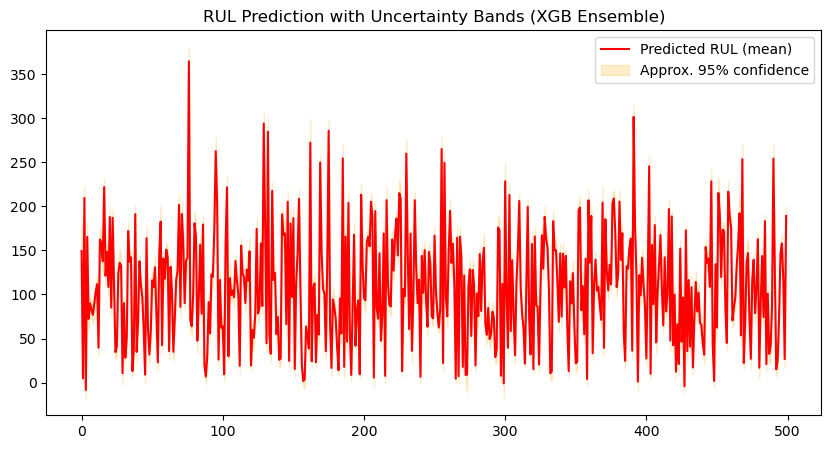

In [55]:
# Assuming X_train, y_train, X_test are already defined
y_mean, y_std = xgb_ensemble_predictions(x_train, y_train, x_test[:500], n_models=30)

plt.figure(figsize=(10,5))
plt.plot(y_mean, label="Predicted RUL (mean)", color="red")
plt.fill_between(range(len(y_mean)), y_mean - 2*y_std, y_mean + 2*y_std,
                 alpha=0.2, color="orange", label="Approx. 95% confidence")
plt.legend()
plt.title("RUL Prediction with Uncertainty Bands (XGB Ensemble)")
plt.show()


In [56]:
y_mean, y_std = xgb_ensemble_predictions(x_train, y_train, x_test[:500], n_models=30)
mean_prediction = y_mean
uncertainty = y_std
print("Mean Prediction:", mean_prediction)
print("Uncertainty:", uncertainty)

/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:52:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:52:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:52:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:52:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:

Mean Prediction: [149.34743     4.811921  209.48965    -8.330879  165.3089     72.25092
  89.815025   82.95782    76.783615   90.04204   102.660416  111.62478
  39.50565   162.43985   158.73228   137.61952   221.81787   121.16866
 148.49387   108.519196  187.92023    85.09066   186.87059   110.73623
  34.560757   41.42438   123.94698   135.88284   132.57202    10.700194
  90.194725   28.422188   50.3442    171.91496   137.07455   142.19218
  13.1124115  38.744545  191.1452     34.891224   68.72841   137.63246
 110.67671    97.67274    60.41433     9.061038  163.9418     62.943123
  31.950785   57.662987  116.046135  108.24435   130.88191    76.55916
  22.995384  145.37108   182.61351    42.456028  140.78084   117.89593
 150.77286   142.00282    35.77449   131.34947   103.56776    34.98795
  72.181305  116.58248   126.907684  201.52646    85.971954  191.2585
 159.2856     90.12839   138.61035   141.5331    364.3528     70.95276
  64.00681    98.51372   180.72507   165.46344    47.498577

In [57]:
lower = mean_prediction - 1.96 * uncertainty
upper = mean_prediction + 1.96 * uncertainty
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: [ 1.21108124e+02 -2.38003778e+00  1.96603134e+02 -1.69826717e+01
  1.48978607e+02  5.84249878e+01  8.23364258e+01  7.34845886e+01
  6.73007355e+01  7.70759430e+01  9.21354675e+01  1.02150627e+02
  3.10030117e+01  1.47443481e+02  1.49457581e+02  1.22986023e+02
  2.11542374e+02  1.11084892e+02  1.37210464e+02  9.60848389e+01
  1.75975586e+02  7.69904861e+01  1.76901840e+02  9.87819443e+01
  2.73877373e+01  3.18052483e+01  1.11729927e+02  1.20460289e+02
  1.23925194e+02 -1.39579487e+00  8.34645157e+01  2.10429859e+01
  4.09337540e+01  1.61219879e+02  1.30112701e+02  1.33275070e+02
  5.64358425e+00  2.78256035e+01  1.81119537e+02  2.37077751e+01
  5.91413193e+01  1.29535751e+02  1.00245071e+02  8.77526245e+01
  4.70289307e+01 -3.23389053e-01  1.51492645e+02  5.29646454e+01
  2.12130280e+01  4.55181007e+01  1.06652634e+02  9.60143280e+01
  1.18269325e+02  6.32834854e+01  1.36802034e+01  1.32179718e+02
  1.64262131e+02  3.31170311e+01  1.32795441e+02  1.03999481e+02
  1.42999268

In [58]:
RPI = (upper - lower) / np.abs(mean_prediction)
print("RPI:", RPI)

RPI: [ 0.37816927  2.9892254   0.12302775  2.0770419   0.19757305  0.38271996
  0.16653337  0.22838664  0.24700269  0.2880009   0.20504394  0.16974998
  0.4304517   0.18463904  0.1168597   0.21266603  0.09264806  0.16644196
  0.15197128  0.22916418  0.1271246   0.19038926  0.10669148  0.21590558
  0.4150962   0.46441892  0.19713351  0.22699787  0.1304472   2.2608914
  0.14923732  0.5192565   0.3738443   0.12442295  0.10157761  0.12542342
  1.1391996   0.5636376   0.10490104  0.6410465   0.27898476  0.11765698
  0.18850651  0.20312962  0.44312     2.0713801   0.15187289  0.3170633
  0.6721435   0.42123672  0.16189253  0.22597058  0.19273226  0.34680822
  0.8101784   0.18148535  0.200986    0.43993738  0.11344438  0.2357409
  0.10311657  0.13447647  0.54206455  0.1602799   0.15376101  0.616865
  0.324372    0.17279877  0.25935924  0.11997528  0.28946206  0.14893082
  0.16620919  0.17182876  0.23147534  0.16593692  0.08283011  0.32677487
  0.34929442  0.28435773  0.15508918  0.1789498   0

In [25]:
from scipy.stats import spearmanr
def stability_score(y_pred):
    return np.mean(np.diff(y_pred) < 0)
def trandability_score(y_true, y_pred):
    corr,_ = spearmanr(y_true, y_pred)
    return corr
def prognostic_horizon(y_true, y_pred, threshold = 0.2):
    y_true,y_pred = np.array(y_true), np.array(y_pred)
    tol = threshold * np.max(y_true)
    abs_err = np.abs(y_true - y_pred)
    within = np.where(abs_err <= tol)[0]
    return 0 if len(within)==0 else len(y_true)-within[0]
def alpha_lambda_accureacy(y_true, y_pred, alpha = 0.1, lambd= 0.2):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    abs_err = np.abs(y_true - y_pred)
    within_alpha = abs_err <= alpha * y_true
    valid = y_true / np.max(y_true) >= lambd
    return np.mean(within_alpha & valid)


In [27]:
ss = stability_score(y_pred)
print("Stability :",ss)
ts = trandability_score(y_test,y_pred)
print("Trandability Score :",ts)
ph = prognostic_horizon(y_test, y_pred)
print("Prognostic Horizon :",ph)
ala = alpha_lambda_accureacy(y_test,y_pred)
print("alpha Lambda accureacy :",ala)

Stability : 0.4973339796412991
Trandability Score : 0.9993361709480348
Prognostic Horizon : 4127
alpha Lambda accureacy : 0.07079355728223993


In [ ]:
predicttion=best_model.predict(x_test)
type(predicttion)
print(predicttion[34])
print(y_test.iloc[34])

Evaluate Random Forest Regeressor Model

In [109]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Suppose df_train, df_test, y_train are already defined

# 1. Find all op_mode_* columns that actually exist in df_train and df_test
op_mode_cols_train = [col for col in x_train.columns if col.startswith('op_mode_')]
op_mode_cols_test = [col for col in x_test.columns if col.startswith('op_mode_')]

# Take the intersection to avoid missing columns
op_mode_cols = list(set(op_mode_cols_train) & set(op_mode_cols_test))
print("Columns to process:", op_mode_cols)

# 2. Convert these columns to numeric (or category)
x_train[op_mode_cols] = x_train[op_mode_cols].apply(pd.to_numeric, errors='coerce')
x_test[op_mode_cols] = x_test[op_mode_cols].apply(pd.to_numeric, errors='coerce')


# 3. Define the RandomForestRegressor
model_2 = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
   
)

# 4. Fit the model
model_2.fit(x_train, y_train)

# 5. Make predictions
preds_train = model_2.predict(x_train)
preds_test = model_2.predict(x_test)

print("Training predictions sample:", preds_train[:5])
print("Test predictions sample:", preds_test[:5])



Columns to process: ['op_mode_0.01_0.0_100.0', 'op_mode_0.01_-0.0_100.0', 'op_mode_0.0_0.0_100.0', 'op_mode_-0.0_-0.0_100.0', 'op_mode_-0.01_-0.0_100.0', 'op_mode_-0.0_0.0_100.0', 'op_mode_-0.01_0.0_100.0', 'op_mode_0.0_-0.0_100.0']
Training predictions sample: [169.122 115.374 114.702 126.826 242.868]
Test predictions sample: [130.42    2.2   209.96    0.    178.606]


In [110]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[200,400,600],
    'min_samples_split':[2,3],
    'min_samples_leaf':[1,3,5],
    'max_depth':[20,30,40]
}

grid_search = GridSearchCV(
    estimator=model_2,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # Use RMSE or other metrics if you like
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearch
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [65]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_2, x_train, y_train, cv=5)  # 5-fold CV
print("CV scores:", scores)
print("Average CV score:", scores.mean())
# Fit GridSearch
grid_search.fit(x_train, y_train)

/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


KeyboardInterrupt: 

In [ ]:
best_params = grid_search.best_params_
print((grid_search.best_params_))
print(grid_search.best_score_)


In [ ]:
best_model = RandomForestRegressor(**best_params)
best_model.fit(x_train, y_train)

/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


KeyboardInterrupt: 

In [67]:
class AccureacyScore:
  def __init__(self, y_true, y_pred):
    self.y_true = y_true
    self.y_pred = y_pred

  def rmse(self):
    return np.sqrt(mean_squared_error(self.y_true, self.y_pred))
  def mse(self):
    return mean_squared_error(self.y_true, self.y_pred)
  def r2_score(self):
    return r2_score(self.y_true, self.y_pred)
  def mae(self):
    return mean_absolute_error(self.y_true, self.y_pred)
  def mape(self):
    return mean_absolute_percentage_error(self.y_true, self.y_pred)
  def nasa_phm_score(self):
    score = 0
    for true, pred in zip(y_test, y_pred):
        error = pred - true
        if error < 0:
            score += np.exp(-error/13) - 1
        else:
            score += np.exp(error/10) - 1
    return score
  


In [111]:
y_pred = model_2.predict(x_test)
eveluate = AccureacyScore(y_test, y_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

Root Mean Squared Error: 5.35600561417593
Mean Squared Error: 28.68679613908408
R2_score: 0.993721146307444
Mean Absolute Error: 1.8608335352556336
Mean Absolute Percentage Error: 0.014926406080546394
NASA_PHM Score: 7669.51558935484


In [ ]:
y_pred = best_model.predict(x_test)
eveluate = AccureacyScore(y_test, y_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

**MC_Dropout for Mean & Uncertainty Predict**

In [116]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.utils import resample

def RFR_ensemble_predictions(X_train, y_train, X_test, n_models=30):
    """
    Train an ensemble of RandomForestRegressor models on bootstrapped samples and
    return mean and std predictions for X_test.
    """
    preds = []

    for i in range(n_models):
        # Bootstrap sample
        X_resampled, y_resampled = resample(X_train, y_train, random_state=i)

        # Train RFR model
        model = model_2
        model.fit(X_resampled, y_resampled)

        # Predict
        preds.append(model.predict(X_test))

    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    std_pred = preds.std(axis=0)

    return mean_pred, std_pred

In [117]:
# Assuming X_train, y_train, X_test are already defined
y_mean, y_std = RFR_ensemble_predictions(x_train, y_train, x_test[:500], n_models=30)

plt.figure(figsize=(10,5))
plt.plot(y_mean, label="Predicted RUL (mean)", color="red")
plt.fill_between(range(len(y_mean)), y_mean - 2*y_std, y_mean + 2*y_std,
                 alpha=0.2, color="orange", label="Approx. 95% confidence")
plt.legend()
plt.title("RUL Prediction with Uncertainty Bands (RFR Ensemble)")
plt.show()


KeyboardInterrupt: 

In [114]:
y_mean, y_std = RFR_ensemble_predictions(x_train, y_train, x_test[:500], n_models=30)
mean_prediction = y_mean
uncertainty = y_std
print("Mean Prediction:", mean_prediction)
print("Uncertainty:", uncertainty)

KeyboardInterrupt: 

In [ ]:
lower = mean_prediction - 1.96 * uncertainty
upper = mean_prediction + 1.96 * uncertainty
print("Lower Bound:", lower)
print("Upper Bound:", upper)

In [ ]:
RPI = (upper - lower) / np.abs(mean_prediction)
print("RPI:", RPI)

In [118]:
!pip install Optuna
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    # Hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 20, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 7),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 7),

        # Regularization paramaters
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-8, 10.0, log=True),

        # Tree Method
        "random_state": 42,
        "n_jobs": -1
    }

    # Build model
    model = RandomForestRegressor(**params)

    # Fit model
    model.fit(
        x_train, y_train,
    )

     # Predict & calculate RMSE
    preds = model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse

In [ ]:
study = optuna.create_study(directions = ["minimize"])
study.optimize(objective, n_trials=40, show_progress_bar = True)  # increase trials for better

[I 2026-01-21 22:06:00,393] A new study created in memory with name: no-name-4439d5b3-e3f1-461a-94da-792b5307c845
Best trial: 0. Best value: 5.50526:   2%|▎         | 1/40 [02:57<1:55:22, 177.50s/it]

[I 2026-01-21 22:08:57,896] Trial 0 finished with value: 5.505258857184347 and parameters: {'n_estimators': 911, 'max_depth': 34, 'min_samples_split': 5, 'min_samples_leaf': 4, 'ccp_alpha': 1.4444874511169806e-08}. Best is trial 0 with value: 5.505258857184347.


Best trial: 0. Best value: 5.50526:   5%|▌         | 2/40 [04:06<1:11:54, 113.53s/it]

[I 2026-01-21 22:10:06,644] Trial 1 finished with value: 5.62579556490291 and parameters: {'n_estimators': 350, 'max_depth': 43, 'min_samples_split': 5, 'min_samples_leaf': 5, 'ccp_alpha': 7.713840823168424e-07}. Best is trial 0 with value: 5.505258857184347.


Best trial: 0. Best value: 5.50526:   8%|▊         | 3/40 [05:33<1:02:40, 101.62s/it]

[I 2026-01-21 22:11:34,103] Trial 2 finished with value: 5.863608626348814 and parameters: {'n_estimators': 462, 'max_depth': 46, 'min_samples_split': 2, 'min_samples_leaf': 7, 'ccp_alpha': 2.37617409556416e-08}. Best is trial 0 with value: 5.505258857184347.


Best trial: 3. Best value: 5.29695:  10%|█         | 4/40 [07:05<58:41, 97.82s/it]   

[I 2026-01-21 22:13:06,097] Trial 3 finished with value: 5.296946010766589 and parameters: {'n_estimators': 378, 'max_depth': 40, 'min_samples_split': 2, 'min_samples_leaf': 2, 'ccp_alpha': 6.405711827117836e-05}. Best is trial 3 with value: 5.296946010766589.


Best trial: 3. Best value: 5.29695:  12%|█▎        | 5/40 [10:34<1:20:25, 137.88s/it]

[I 2026-01-21 22:16:34,999] Trial 4 finished with value: 5.856079984723352 and parameters: {'n_estimators': 820, 'max_depth': 24, 'min_samples_split': 3, 'min_samples_leaf': 7, 'ccp_alpha': 4.816167790451632e-07}. Best is trial 3 with value: 5.296946010766589.


In [ ]:
best_trials = study.best_trials
print(best_trials[0])
best_params = study.best_trials
print(best_params)

In [ ]:
best_model = RandomForestRegressor(**study.best_params)
best_model.fit(x_train, y_train)

In [ ]:
y_pred = best_model.predict(x_test)
eveluate = AccureacyScore(y_test, y_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

In [24]:
def NASA_phm_score(y_true, y_pred):
    score = 0
    for true, pred in zip(y_test, y_pred):
        error = pred - true
        if error < 0:
            score += np.exp(-error/13) - 1
        else:
            score += np.exp(error/10) - 1
    return score

print("NASA_PHM Score:", NASA_phm_score(y_test, y_pred))


NameError: name 'y_test' is not defined

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.utils import resample

def RFR_ensemble_predictions(X_train, y_train, X_test, n_models=30):
    """
    Train an ensemble of RandomForestRegressor models on bootstrapped samples and
    return mean and std predictions for X_test.
    """
    preds = []

    for i in range(n_models):
        # Bootstrap sample
        X_resampled, y_resampled = resample(X_train, y_train, random_state=i)

        # Train RFR model
        model = best_model
        model.fit(X_resampled, y_resampled)

        # Predict
        preds.append(model.predict(X_test))

    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    std_pred = preds.std(axis=0)

    return mean_pred, std_pred

In [ ]:
# Assuming X_train, y_train, X_test are already defined
y_mean, y_std = RFR_ensemble_predictions(x_train, y_train, x_test[:500], n_models=30)

plt.figure(figsize=(10,5))
plt.plot(y_mean, label="Predicted RUL (mean)", color="red")
plt.fill_between(range(len(y_mean)), y_mean - 2*y_std, y_mean + 2*y_std,
                 alpha=0.2, color="orange", label="Approx. 95% confidence")
plt.legend()
plt.title("RUL Prediction with Uncertainty Bands (RFR Ensemble)")
plt.show()


In [ ]:
predicttion=best_model.predict(x_test)
type(predicttion)
print(predicttion[27])
print(y_test.iloc[27])

Build LSTM MODEL FOR RUL PREDICTION

In [1]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names

In [4]:
dftrain = pd.read_csv('/Users/soujanyadutta/VS_Code_file/Nasa_Turbofan_Rul_Prediction/CMaps/train_FD001.txt',sep='\s+',header=None,index_col=False,names=col_names)
dfvalid = pd.read_csv('/Users/soujanyadutta/VS_Code_file/Nasa_Turbofan_Rul_Prediction/CMaps/test_FD001.txt',sep='\s+',header=None,index_col=False,names=col_names)
y_valid = pd.read_csv('/Users/soujanyadutta/VS_Code_file/Nasa_Turbofan_Rul_Prediction/CMaps/RUL_FD001.txt',sep='\s+',header=None,index_col=False,names=['RUL'])
dfvalid.shape

(13096, 26)

In [5]:
train = dftrain.copy()
valid = dfvalid.copy()

In [6]:
# Delete the Columns where verience is '0'
train = train.drop(['s_1','s_5','s_10','s_16','s_18','s_19'], axis=1)

train

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640


In [7]:
train_grouped_by_unit=train.groupby('unit_number').max()
max_time_cycle=train_grouped_by_unit['time_cycles']
marged = train.merge(max_time_cycle.to_frame(name='max_time_cycle'), left_on='unit_number', right_index=True)
marged['RUL'] = marged['max_time_cycle'] - marged['time_cycles']
marged = marged.drop('max_time_cycle', axis=1)
train = marged
train

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_6,s_7,...,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,643.49,1597.98,1428.63,21.61,551.43,...,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,643.54,1604.50,1433.58,21.61,550.86,...,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,643.42,1602.46,1428.18,21.61,550.94,...,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,643.23,1605.26,1426.53,21.61,550.68,...,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,1


In [ ]:
f

In [8]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
sample_df = train.dropna()
feature_col = [c for c in sample_df.columns if c not in['unit_number','time_cycles','RUL']]

x= sample_df[feature_col]

scaler_1 = StandardScaler()
scaler_2 = MinMaxScaler()

sample_df[feature_col] = scaler_1.fit_transform(x)

sample_df[feature_col] = scaler_2.fit_transform(x)




In [9]:
def create_sequences(df,Seq_len,feature):
    x = []
    y = []
    for eng_id in df['unit_number'].unique():
        f_data = sample_df[sample_df['unit_number'] == eng_id][feature+['RUL']].values
        for i in range(len(f_data)-Seq_len):
            x.append(f_data[i:i+Seq_len]-1)
            y.append(f_data[i+Seq_len,-1])
    return np.array(x), np.array(y)


In [10]:
seq_len = 30
x_seq ,y_seq = create_sequences(train,seq_len,feature_col)

In [11]:
print(x_seq.shape)
print(y_seq.shape)

(17631, 30, 19)
(17631,)


In [12]:
len(x_seq)==len(y_seq)

True

In [13]:
from sklearn.model_selection import train_test_split
x_tr, x_v, y_tr, y_v = train_test_split(x_seq,y_seq, test_size=0.2, random_state=42)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np


model_3 = Sequential([
    LSTM(256, return_sequences=True,input_shape=(x_tr.shape[1],x_tr.shape[2])),
    Dropout(0.3),
    LSTM(128),
    Dense(64,activation='linear'),
    Dense(1)
    ])
    

   
model_3.compile(optimizer=Adam(learning_rate=0.0005),loss='mae')

model_3.summary()

/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 256)        │       282,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488,065 (1.86 MB)

 Trainable params: 488,065 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
hist = model_3.fit(x_tr,y_tr,validation_data=(x_v,y_v),epochs=30,batch_size=64,verbose=1)

Epoch 1/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 31.1329 - val_loss: 4.9135
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 2.9250 - val_loss: 1.8490
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1.7424 - val_loss: 1.1744
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1.4477 - val_loss: 0.9828
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1.1405 - val_loss: 0.9672
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1.0932 - val_loss: 1.2973
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 1.0354 - val_loss: 0.8875
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.9372 - val_loss: 0.8008
Epoch 9/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.8586 - val_loss: 0.5766
Epoch 10/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.9054 - val_loss: 0.6308
Epoch 11/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.8528 - val_loss: 0.7787
Epoch 12/30
221/221 ━━━━━━━━━━━━━━━━━━━━

In [16]:
y_pred = model_3.predict(x_v).flatten()
eveluate = AccureacyScore(y_v, y_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


NameError: name 'AccureacyScore' is not defined

In [17]:
y_pred = model_3.predict(x_v).flatten()

def NASA_phm_score(y_v, y_pred):
    score = 0
    for true, pred in zip(y_v, y_pred):
        error = pred - true
        if error < 0:
            score += np.exp(-error/13) - 1
        else:
            score += np.exp(error/10) - 1
    return score

print("NASA_PHM Score:", NASA_phm_score(y_v, y_pred))


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
NASA_PHM Score: 152.39230307965306


In [90]:
from scipy.stats import spearmanr
def stability_score(y_pred):
    return np.mean(np.diff(y_pred) < 0)
def trandability_score(y_true, y_pred):
    corr,_ = spearmanr(y_true, y_pred)
    return corr
def prognostic_horizon(y_true, y_pred, threshold = 0.2):
    y_true,y_pred = np.array(y_true), np.array(y_pred)
    tol = threshold * np.max(y_true)
    abs_err = np.abs(y_true - y_pred)
    within = np.where(abs_err <= tol)[0]
    return 0 if len(within)==0 else len(y_true)-within[0]
def alpha_lambda_accureacy(y_true, y_pred, alpha = 0.1, lambd= 0.2):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    abs_err = np.abs(y_true - y_pred)
    within_alpha = abs_err <= alpha * y_true
    valid = y_true / np.max(y_true) >= lambd
    return np.mean(within_alpha & valid)


In [91]:
ss = stability_score(y_pred)
print("Stability :",ss)
ts = trandability_score(y_v,y_pred)
print("Trandability Score :",ts)
ph = prognostic_horizon(y_v, y_pred)
print("Prognostic Horizon :",ph)
ala = alpha_lambda_accureacy(y_v,y_pred)
print("alpha Lambda accuracy :",ala)

Stability : 0.5
Trandability Score : 0.9999856012378204
Prognostic Horizon : 3527
alpha Lambda accuracy : 0.6331159625744258


In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

model_4 = Sequential([
    GRU(256, return_sequences=True,input_shape=(x_tr.shape[1],x_tr.shape[2])),
    Dropout(0.3),
    GRU(128),
    Dense(64,activation='linear'),
    Dense(1)
    ])
    

   
model_4.compile(optimizer=Adam(learning_rate=0.0005),loss='mae')

model_4.summary()

/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 256)        │       212,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,281 (1.41 MB)

 Trainable params: 369,281 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
history = model_4.fit(x_tr,y_tr,validation_data=(x_v,y_v),epochs=30,batch_size=64,verbose=1)

Epoch 1/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 30.7531 - val_loss: 6.0990
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 2.9051 - val_loss: 1.6564
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 1.7214 - val_loss: 1.3876
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 1.3470 - val_loss: 1.1170
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 1.2451 - val_loss: 1.3409
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 1.0465 - val_loss: 1.1927
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.9356 - val_loss: 0.8066
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.9489 - val_loss: 0.3977
Epoch 9/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.8751 - val_loss: 0.7694
Epoch 10/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.8981 - val_loss: 0.6148
Epoch 11/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.8740 - val_loss: 0.5151
Epoch 12/30
221/221 ━━━━━━━━━━━━━━━━━━━━

In [94]:
y_pred = model_4.predict(x_v).flatten()
eveluate = AccureacyScore(y_v, y_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Root Mean Squared Error: 0.621316753495023
Mean Squared Error: 0.38603450817359514
R2_score: 0.9998966087158554
Mean Absolute Error: 0.5002282034803255


In [95]:
y_pred = model_4.predict(x_v).flatten()

def NASA_phm_score(y_v, y_pred):
    score = 0
    for true, pred in zip(y_v, y_pred):
        error = pred - true
        if error < 0:
            score += np.exp(-error/13) - 1
        else:
            score += np.exp(error/10) - 1
    return score

print("NASA_PHM Score:", NASA_phm_score(y_v, y_pred))


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
NASA_PHM Score: 164.78094751254346


In [96]:
ss = stability_score(y_pred)
print("Stability :",ss)
ts = trandability_score(y_v,y_pred)
print("Trandability Score :",ts)
ph = prognostic_horizon(y_v, y_pred)
print("Prognostic Horizon :",ph)
ala = alpha_lambda_accureacy(y_v,y_pred)
print("alpha Lambda accureacy :",ala)

Stability : 0.5002836074872377
Trandability Score : 0.9999856013061957
Prognostic Horizon : 3527
alpha Lambda accureacy : 0.6331159625744258


In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D,LSTM, Dense, Dropout


model_5 = Sequential([
    Conv1D(
        filters = 128,
        kernel_size = 6,
        activation = 'relu',
        input_shape =(x_tr.shape[1],x_tr.shape[2])
    ),
    MaxPooling1D(pool_size=2),
    LSTM(128, return_sequences=True,input_shape=(x_tr.shape[1],x_tr.shape[2])),
    Dropout(0.3),
    LSTM(64),
    Dense(1)

])

model_5.compile(optimizer=Adam(learning_rate=0.0005),loss='mae')

model_5.summary()


/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/soujanyadutta/miniforge3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 25, 128)        │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,777 (764.75 KB)

 Trainable params: 195,777 (764.75 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
history = model_5.fit(x_tr,y_tr,validation_data=(x_v,y_v),epochs=30,batch_size=64,verbose=1)

Epoch 1/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 83.3689 - val_loss: 78.1573
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 75.3113 - val_loss: 71.7285
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 69.1681 - val_loss: 65.8618
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 63.4889 - val_loss: 60.3157
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 58.2548 - val_loss: 55.2237
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 53.3994 - val_loss: 50.5786
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 48.8604 - val_loss: 46.3202
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 44.6573 - val_loss: 42.2206
Epoch 9/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 40.7886 - val_loss: 38.3018
Epoch 10/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 37.1526 - val_loss: 34.8459
Epoch 11/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 33.8300 - val_loss: 31.6662
Epoch 12/30
221/221

In [99]:
y_pred = model_5.predict(x_v).flatten()
eveluate = AccureacyScore(y_v, y_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Root Mean Squared Error: 19.12028410220728
Mean Squared Error: 365.58526414912035
R2_score: 0.902085618968204
Mean Absolute Error: 5.569457110548817


In [100]:
y_pred = model_5.predict(x_v).flatten()

def NASA_phm_score(y_v, y_pred):
    score = 0
    for true, pred in zip(y_v, y_pred):
        error = pred - true
        if error < 0:
            score += np.exp(-error/13) - 1
        else:
            score += np.exp(error/10) - 1
    return score

print("NASA_PHM Score:", NASA_phm_score(y_v, y_pred))


111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
NASA_PHM Score: 1020274.9685782106


In [101]:
ss = stability_score(y_pred)
print("Stability :",ss)
ts = trandability_score(y_v,y_pred)
print("Trandability Score :",ts)
ph = prognostic_horizon(y_v, y_pred)
print("Prognostic Horizon :",ph)
ala = alpha_lambda_accureacy(y_v,y_pred)
print("alpha Lambda accureacy :",ala)

Stability : 0.500850822461713
Trandability Score : 0.999500177785297
Prognostic Horizon : 3527
alpha Lambda accureacy : 0.5523107456762121


In [19]:
y1_pred = model_1.predict(x_test)
eveluate = AccureacyScore(y_test, y1_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

NameError: name 'model_1' is not defined

In [40]:
y2_pred = model_2.predict(x_test)
eveluate = AccureacyScore(y_test, y2_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

Root Mean Squared Error: 39.24262060183746
Mean Squared Error: 1539.9832716997578
R2_score: 0.667795172074398
Mean Absolute Error: 28.80906053268765
Mean Absolute Percentage Error: 0.43634518815531204
NASA_PHM Score: 1977233.994288292


In [22]:
y3_pred = model_3.predict(x_v)
eveluate = AccureacyScore(y_v, y3_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Root Mean Squared Error: 1.0983742959098401
Mean Squared Error: 1.2064260939154372
R2_score: 0.9996768839561374
Mean Absolute Error: 0.7360181312280334
Mean Absolute Percentage Error: 952435017556.7156


NameError: name 'y_test' is not defined

In [43]:
y4_pred = model_4.predict(x_v)
eveluate = AccureacyScore(y_v, y4_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Root Mean Squared Error: 112.48528081846413
Mean Squared Error: 12652.938400808735
R2_score: -2.4412756246510288
Mean Absolute Error: 94.74196951729911
Mean Absolute Percentage Error: 0.6794165105563466
NASA_PHM Score: 1977233.994288292


In [44]:
y5_pred = model_5.predict(x_v)
eveluate = AccureacyScore(y_v, y5_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
Root Mean Squared Error: 134.47944417580806
Mean Squared Error: 18084.720905834274
R2_score: -3.9185815389638297
Mean Absolute Error: 120.03301743098667
Mean Absolute Percentage Error: 0.9190871978801417
NASA_PHM Score: 1977233.994288292
